In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import shutil
import zipfile
import tempfile
from PIL import Image, ImageFile
import cv2
from sklearn.model_selection import train_test_split
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import tensorflow.keras.backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
root_path = "/kaggle/input/fashion-augmented-dataset/Fashion_Reccomendation1"

In [ ]:
print(f"Root directory:{root_path}")

In [2]:
root_path = "/kaggle/input/fashion-augmented-dataset/Fashion_Recommendation/Fashion_Reccomendation1"
image_extensions = {".jpg", ".jpeg", ".png", ".gif"} 

classes = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

print("Classes present in the dataset and their image counts:")
for cls in classes:
    class_path = os.path.join(root_path, cls)
    num_images = sum(1 for file in os.listdir(class_path) if os.path.splitext(file)[1].lower() in image_extensions)
    print(f"{cls}: {num_images} images")

Classes present in the dataset and their image counts:
Wedding: 534 images
Formal_Wear: 510 images
Casual_Wear: 578 images
Winter_Wear: 599 images
Festive_Wear: 575 images
Daily_Wear: 605 images
Common: 600 images
Party_Wear: 617 images


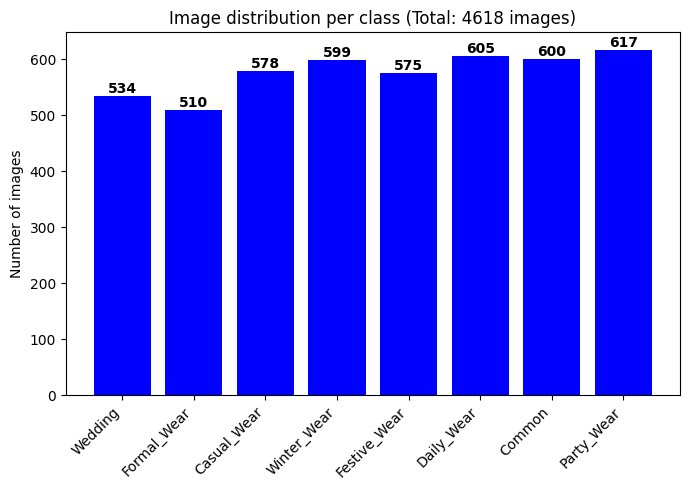

In [3]:
import pathlib
data_dir = pathlib.Path('/kaggle/input/fashion-augmented-dataset/Fashion_Recommendation/Fashion_Reccomendation1')

image_paths = list(data_dir.glob('**/*.jpg')) + list(data_dir.glob('**/*.jpeg')) + list(data_dir.glob('**/*.png')) + list(data_dir.glob('**/*.gif'))
image_count = len(image_paths)

data = dict()

for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        num_images = len(list(class_dir.rglob('*.jpg'))) + len(list(class_dir.rglob('*.jpeg'))) + len(list(class_dir.rglob('*.png'))) + len(list(class_dir.rglob('*.gif')))
        data[class_dir.name] = num_images

plt.figure(figsize=(7, 5))
bars = plt.bar(data.keys(), data.values(), color='b')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of images')
plt.title(f'Image distribution per class (Total: {image_count} images)')
plt.tight_layout()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, str(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import random

# Set parent directory containing all classes
image_dir = "/kaggle/input/fashion-augmented-dataset/Fashion_Reccomendation1/"
classes = [d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]

# Create figure with subplots
max_images_per_class = 10  # Number of images to show per class
num_cols = max_images_per_class + 1  # 1 column for class name + images
num_rows = len(classes)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 2*num_rows))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for row_idx, class_name in enumerate(classes):
    class_path = os.path.join(image_dir, class_name)
    valid_images = []
    
    # Collect non-augmented images excluding jo5.png
    for f in os.listdir(class_path):
        if (not f.startswith('aug') and 
            f.lower() != 'jo5.png' and 
            os.path.isfile(os.path.join(class_path, f))):
            
            try:
                # Verify image is readable
                with Image.open(os.path.join(class_path, f)) as img:
                    img.verify()
                valid_images.append(f)
            except (UnidentifiedImageError, IOError, Exception) as e:
                print(f"Skipping corrupted/invalid: {class_name}/{f} - {str(e)}")
                continue

    # Randomly select images (or take first if not enough)
    selected_images = random.sample(valid_images, min(max_images_per_class, len(valid_images))) if valid_images else []

    # Class name column
    ax = axes[row_idx, 0] if num_rows > 1 else axes[0]
    ax.text(0.5, 0.5, class_name, 
            ha='center', va='center', 
            fontsize=22, rotation=0,
            fontweight='bold')
    ax.axis('off')
    
    # Display images
    for col_idx, img_file in enumerate(selected_images, start=1):
        ax = axes[row_idx, col_idx] if num_rows > 1 else axes[col_idx]
        try:
            img_path = os.path.join(class_path, img_file)
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.axis('off')
        except Exception as e:
            print(f"Error displaying {class_name}/{img_file}: {e}")
            ax.axis('off')
    
    # Hide empty subplots
    for col_idx in range(len(selected_images)+1, num_cols):
        ax = axes[row_idx, col_idx] if num_rows > 1 else axes[col_idx]
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
root_path = "/kaggle/input/fashion-augmented-dataset/Fashion_Recommendation/Fashion_Reccomendation1"
image_extensions = {".jpg", ".jpeg", ".png", ".gif"}
total_images = 0

for subdir, _, files in os.walk(root_path):
    total_images += sum(1 for file in files if os.path.splitext(file)[1].lower() in image_extensions)

print("Total images in the dataset:", total_images)

In [4]:
root_path = "/kaggle/input/fashion-augmented-dataset/Fashion_Recommendation/Fashion_Reccomendation1"
IMG_SIZE = (224, 224)

# Function to process images
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Could not load image: " + img_path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0

    return img_to_array(img)

all_images = []
labels = []

for class_folder in os.listdir(root_path):
    class_path = os.path.join(root_path, class_folder)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            processed_img = preprocess_image(img_path)

            if processed_img is not None:
                all_images.append(processed_img)
                labels.append(class_folder)

X = np.array(all_images)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=0)

print("Preprocessing complete! Processed " + str(len(X)) + " images.")
print("Training Data: " + str(len(X_train)) + " images")
print("Testing Data: " + str(len(X_test)) + " images")

Preprocessing complete! Processed 4618 images.
Training Data: 4156 images
Testing Data: 462 images


# **DenseNet201**

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = len(set(y_train))

label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_test_numeric = label_encoder.transform(y_test)
joblib.dump(label_encoder, 'label_encoder.pkl')

y_train_encoded = to_categorical(y_train_numeric, num_classes=NUM_CLASSES)
y_test_encoded = to_categorical(y_test_numeric, num_classes=NUM_CLASSES)

base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# early_stopping = EarlyStopping(
#     monitor='val_loss',   # Metric to monitor (validation loss)
#     patience=5,           # Number of epochs with no improvement before stopping
#     restore_best_weights=True,  # Restore model weights from the epoch with best value
#     verbose=1,            # Show messages
#     mode='min'            # Direction to monitor (minimize loss)
# )

history = model.fit(
    X_train, y_train_encoded,
    epochs=150,
    validation_data=(X_test, y_test_encoded)
)

model.save('personalized_fashion_densenet201.keras')

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

print(classification_report(y_test_numeric, y_pred_classes, target_names=label_encoder.classes_))

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

print(classification_report(y_test_numeric, y_pred_classes, target_names=label_encoder.classes_))

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

cm = confusion_matrix(y_test_numeric, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# **MobileNetV2**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = len(set(y_train))

label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_test_numeric = label_encoder.transform(y_test)

y_train_encoded = to_categorical(y_train_numeric, num_classes=NUM_CLASSES)
y_test_encoded = to_categorical(y_test_numeric, num_classes=NUM_CLASSES)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_encoded,
    epochs=150,
    validation_data=(X_test, y_test_encoded)
)

model.save('personalized_fashion_mobilenet_v2.keras')

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

print(classification_report(y_test_numeric, y_pred_classes, target_names=label_encoder.classes_))

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

cm = confusion_matrix(y_test_numeric, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# **Xception**

In [ ]:
from tensorflow.keras.applications import Xception
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = len(set(y_train))

label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_test_numeric = label_encoder.transform(y_test)

y_train_encoded = to_categorical(y_train_numeric, num_classes=NUM_CLASSES)
y_test_encoded = to_categorical(y_test_numeric, num_classes=NUM_CLASSES)

base_model = Xception(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_encoded,
    epochs=100,
    validation_data=(X_test, y_test_encoded)
)

model.save('personalized_fashion_inceptionresnet.keras')

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

print(classification_report(y_test_numeric, y_pred_classes, target_names=label_encoder.classes_))

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

label_encoder = LabelEncoder()
y_test_numeric = label_encoder.fit_transform(y_test)

cm = confusion_matrix(y_test_numeric, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [6]:
from tensorflow.keras.models import load_model
model1 = load_model('/kaggle/input/d_m_x_models/keras/default/2/personalized_fashion_densenet201_.keras')
model2 = load_model('/kaggle/input/d_m_x_models/keras/default/2/personalized_fashion_mobilenetv2_.keras')
model3 = load_model('/kaggle/input/d_m_x_models/keras/default/2/personalized_fashion_xception_.keras')

In [7]:
train_dir = "/kaggle/working/train"
test_dir = "/kaggle/working/test"
image_extensions = {".jpg", ".jpeg", ".png", ".gif"}

In [8]:
all_files = []
for subdir, _, files in os.walk(root_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext in image_extensions:
            full_path = os.path.join(subdir, file)
            all_files.append(full_path)

print(f"Total images found: {len(all_files)}")  # Verify this shows 2500

if len(all_files) == 0:
    print("No images found!")
else:
    # Split files
    train_files, test_files = train_test_split(
        all_files, 
        test_size=0.10, 
        random_state=0
    )

Total images found: 4618


In [9]:
def copy_files(file_list, target_dir):
        os.makedirs(target_dir, exist_ok=True)
        copied_count = 0
        for src_path in file_list:
            # Preserve directory structure relative to root_path
            relative_path = os.path.relpath(src_path, root_path)
            dest_path = os.path.join(target_dir, relative_path)
            
            # Create subdirectories if needed
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            
            if not os.path.exists(dest_path):
                shutil.copy(src_path, dest_path)
                copied_count += 1
            else:
                print(f"Skipped duplicate: {dest_path}")
        return copied_count
    
train_count = copy_files(train_files, train_dir)
test_count = copy_files(test_files, test_dir)

print(f"\nTrain images: {train_count}")
print(f"Test images: {test_count}")
print(f"Total copied: {train_count + test_count}/{len(all_files)}")


Train images: 4156
Test images: 462
Total copied: 4618/4618


In [10]:
train_dir = "/kaggle/working/train"
test_dir = "/kaggle/working/test"

In [11]:
img_height = 224
img_width = 224
num_classes = len(set(y_train))
batch_size = 32

In [15]:
train_datagen = ImageDataGenerator( rescale=1./255, rotation_range=30, width_shift_range=0.25, 
                                   height_shift_range=0.25, shear_range=0.25, zoom_range=0.25, 
                                   horizontal_flip=True, fill_mode='nearest' )



test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory( train_dir, 
                                                    target_size=(img_width, img_height), 
                                                    batch_size=batch_size, class_mode='categorical', 
                                                    shuffle=True)

test_generator = test_datagen.flow_from_directory( test_dir, 
                                                  target_size=(img_width, img_height), 
                                                  batch_size=batch_size, class_mode='categorical', 
                                                  shuffle=False )

Found 4155 images belonging to 8 classes.
Found 462 images belonging to 8 classes.


In [17]:
num_samples = len(test_generator)

In [18]:
import os
from glob import glob

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# from keras.utils.np_utils import to_categorical # convert to one-hot-encoding

# from keras.preprocessing.image import ImageDataGenerator
from keras import layers
from keras import Model, Input
from keras.applications.inception_v3 import InceptionV3
from keras.applications.densenet import DenseNet201
from keras.applications.mobilenet import MobileNet

from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


%matplotlib inline
import matplotlib.pyplot as plt
from keras.layers import Input, Lambda, Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from keras.models import Model
from keras.applications.mobilenet import MobileNet
from keras.applications.densenet import DenseNet201
from keras.applications.mobilenet import preprocess_input
from keras.preprocessing import image
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
# from keras.utils.np_utils import to_categorical
from tensorflow.keras.utils import to_categorical
# import numpy as np
# from glob import glob
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import PIL
from PIL import Image
import random
# import os
import shutil
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
np.random.seed(42)
# import pandas as pd
# import numpy as np
# import os
import tensorflow as tf
import cv2
from keras import backend as K
from keras.layers import Layer,InputSpec
import keras.layers as kl
from glob import glob
from sklearn.metrics import roc_curve, auc
from keras.preprocessing import image
from keras.models import Sequential
from sklearn.metrics import roc_auc_score
from keras import callbacks
from keras.callbacks import ModelCheckpoint,EarlyStopping
from  matplotlib import pyplot as plt
from keras import Model
from keras.layers import concatenate,Dense, Conv2D, MaxPooling2D, Flatten,Input,Activation,add,AveragePooling2D,BatchNormalization,Dropout, GlobalAveragePooling2D
%matplotlib inline
import shutil
from sklearn.metrics import  precision_score, recall_score, accuracy_score,classification_report ,confusion_matrix
from tensorflow.python.platform import build_info as tf_build_info
# from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [19]:
predictions1 = model1.predict(test_generator)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step 


In [20]:
predictions1.shape

(462, 8)

In [21]:
y_pred1 = np.argmax(predictions1, axis=1)
targetnames = ['Casual_Wear', 'Common', 'Daily_Wear', 'Festive_Wear', 'Formal_Wear', 'Party_Wear', 'Wedding','Winter_Wear']
#getting the true labels per image
y_true = test_generator.classes
#getting the predicted labels per image
y_prob=predictions1
from keras.utils import to_categorical
y_test = to_categorical(y_true)

# Creating classification report
report = classification_report(y_true, y_pred1, target_names=targetnames)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

 Casual_Wear       1.00      0.98      0.99        56
      Common       0.92      0.99      0.95        67
  Daily_Wear       0.95      0.94      0.95        66
Festive_Wear       0.98      0.90      0.94        63
 Formal_Wear       1.00      0.98      0.99        53
  Party_Wear       1.00      0.96      0.98        53
     Wedding       0.97      1.00      0.98        56
 Winter_Wear       0.92      0.98      0.95        48

    accuracy                           0.97       462
   macro avg       0.97      0.97      0.97       462
weighted avg       0.97      0.97      0.97       462



In [22]:
print(y_pred1)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 1 2 7 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 6 3 3 3 3 3 3 3 3 7 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3 6 2 3 3 3 3 3 3 3 3 3 3 1 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 2 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]


In [23]:
predictions2 = model2.predict(test_generator)

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 566ms/step


In [24]:
#geting predictions on test dataset
y_pred2 = np.argmax(predictions2, axis=1)
targetnames = ['Casual_Wear', 'Common', 'Daily_Wear', 'Festive_Wear', 'Formal_Wear', 'Party_Wear', 'Wedding','Winter_Wear']
#getting the true labels per image
y_true = test_generator.classes
#getting the predicted labels per image
y_prob=predictions2
from keras.utils import to_categorical
y_test = to_categorical(y_true)

# Creating classification report
report = classification_report(y_true, y_pred2, target_names=targetnames)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

 Casual_Wear       1.00      0.82      0.90        56
      Common       0.89      1.00      0.94        67
  Daily_Wear       0.98      0.97      0.98        66
Festive_Wear       1.00      0.97      0.98        63
 Formal_Wear       0.96      0.94      0.95        53
  Party_Wear       1.00      0.96      0.98        53
     Wedding       0.98      1.00      0.99        56
 Winter_Wear       0.85      0.98      0.91        48

    accuracy                           0.96       462
   macro avg       0.96      0.96      0.96       462
weighted avg       0.96      0.96      0.96       462



In [25]:
print(y_pred2)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 2 7 0 0
 0 0 0 7 0 0 0 0 7 0 0 0 7 0 4 1 4 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 7 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 7 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 6 3 3 3 3 3 7 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 1 1 4 4
 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 5 5 1 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 1
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]


In [26]:
predictions3 = model3.predict(test_generator)

15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step


In [27]:
#geting predictions on test dataset
y_pred3 = np.argmax(predictions3, axis=1)
targetnames = ['Casual_Wear', 'Common', 'Daily_Wear', 'Festive_Wear', 'Formal_Wear', 'Party_Wear', 'Wedding','Winter_Wear']
#getting the true labels per image
y_true = test_generator.classes
#getting the predicted labels per image
y_prob=predictions3
from keras.utils import to_categorical
y_test = to_categorical(y_true)

# Creating classification report
report = classification_report(y_true, y_pred3, target_names=targetnames)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

 Casual_Wear       0.98      0.98      0.98        56
      Common       0.94      0.97      0.96        67
  Daily_Wear       0.94      0.95      0.95        66
Festive_Wear       1.00      0.95      0.98        63
 Formal_Wear       1.00      1.00      1.00        53
  Party_Wear       1.00      0.96      0.98        53
     Wedding       1.00      1.00      1.00        56
 Winter_Wear       0.96      1.00      0.98        48

    accuracy                           0.98       462
   macro avg       0.98      0.98      0.98       462
weighted avg       0.98      0.98      0.98       462



In [28]:
print(y_pred3)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 7 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 7 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 2 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 5 5 1 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]


In [29]:
acc_m1 = accuracy_score(y_true, y_pred1)
print(acc_m1)

0.9653679653679653


In [30]:
acc_m2 = accuracy_score(y_true, y_pred2)
print(acc_m2)

0.9567099567099567


In [31]:
acc_m3 = accuracy_score(y_true, y_pred3)
print(acc_m3)

0.9761904761904762


# Dempster Shafer

In [32]:
!pip install py_dempster_shafer

  Preparing metadata (setup.py) ... done
  Created wheel for py_dempster_shafer: filename=py_dempster_shafer-0.7-py3-none-any.whl size=13358 sha256=4061b627176d6d4f4c98f6e37da1b2cdca94fcee2e820f4f437f7dacccf6e9f9
  Stored in directory: /root/.cache/pip/wheels/6c/16/47/07a22828af09bbeef97bcf9af8e0f51d3364253e17e06b5745
Successfully built py_dempster_shafer


In [33]:
import pyds
from pyds import MassFunction, powerset

In [34]:
def DempsterRule(m1, m2):
    ## extract the frame of discernment
    sets=set(m1.keys()).union(set(m2.keys()))
    result=dict.fromkeys(sets,0)
    ## Combination process
    for i in m1.keys():
        for j in m2.keys():
            if set(str(i)).intersection(set(str(j))) == set(str(i)):
                result[i]+=m1[i]*m2[j]
            elif set(str(i)).intersection(set(str(j))) == set(str(j)):
                result[j]+=m1[i]*m2[j]

    ## normalize the results
    f= sum(list(result.values()))
    for i in result.keys():
        result[i] /=f
    return result

In [35]:
def find_elements(max_key):
    str1 = str(max_key)
    subset_elements = []
    for i in labels:
        str2 = str(i)
        index = str1.find(str2)
        if index >= 0:
                subset_elements.append(i)
    return subset_elements

In [36]:
def label_prediction_from_union_3C(prediction1, prediction2, prediction3, max_key):
              sum1 = 0
              sum2 = 0
              sum3=0
              SUM =[]
              subset_elements = find_elements(max_key)
              for i in subset_elements:
                         sum1 = sum1+prediction1[i]
                         sum2 = sum2+prediction2[i]
                         sum3 = sum3+prediction3[i]
              SUM = [sum1, sum2, sum3]
              SUM = np.array(SUM)
              max_index = np.argmax(SUM)
              m_key=-1
              if max_index == 0:
                          max = 0
                          for i in subset_elements:
                                      if prediction1[i] > max:
                                        max = prediction1[i]
                                        m_key = i
                          return m_key
              elif max_index == 1:
                          max = 0
                          for i in subset_elements:
                                      if prediction2[i] > max:
                                        max = prediction2[i]
                                        m_key = i
                          return m_key
              elif max_index == 2:
                          max = 0
                          for i in subset_elements:
                                      if prediction3[i] > max:
                                        max = prediction3[i]
                                        m_key = i
                          return m_key

In [37]:
def label_prediction_3C(combined_mass, prediction1, prediction2, prediction3):
          max_keys = [key for key, value in combined_mass.items() if value == max(combined_mass.values())]
          subset_elements = find_elements(max_keys[0])
          if len(subset_elements) == 1:
                      return subset_elements[0]
          else:
                      return label_prediction_from_union_3C(prediction1, prediction2, prediction3, max_keys[0])

In [38]:
def minimum2(key, prediction):
          subset_elements = find_elements(key)
          sum = np.sum(prediction)
          min=99
          for i in subset_elements:
                       x = prediction[i]/sum
                       if(x<min):
                            min = x
          return min

In [39]:
# DST with no class-biases ;
from collections import Counter
predicted_label = []
labels = [0, 1, 2, 3, 4, 5, 6,7]
for i in range(len(y_true)):

      mult1 = predictions1[i]
      mult2 = predictions2[i]
      mult3 = predictions3[i]

      pset1 = dict.fromkeys(powerset(labels), 0)
      pset2 = dict.fromkeys(powerset(labels), 0)
      pset3 = dict.fromkeys(powerset(labels), 0)

      for key in pset1: pset1[key] = minimum2(key, mult1)
      total = float(sum(pset1.values()))
      for key in pset1: pset1[key] /= total
      #for key in pset1: pset1[key] *= acc_m1
      #total = float(sum(pset1.values()))
      #for key in pset1: pset1[key] /= total

      for key in pset2: pset2[key] = minimum2(key, mult2)
      total = float(sum(pset2.values()))
      for key in pset2: pset2[key] /= total
      #for key in pset2: pset2[key] *= acc_m2
      #total = float(sum(pset2.values()))
      #for key in pset2: pset2[key] /= total

      for key in pset3: pset3[key] = minimum2(key, mult3)
      total = float(sum(pset3.values()))
      for key in pset3: pset3[key] /= total
      #for key in pset3: pset3[key] *= acc_m3
      #total = float(sum(pset3.values()))
      #for key in pset3: pset3[key] /= total



      Combined_mass1 = DempsterRule(pset1, pset2)
      Combined_mass = DempsterRule(Combined_mass1, pset3)
      for key in Combined_mass:
           if str(key) == "frozenset()":
                         Combined_mass[key] = 0

      predicted_label.append(label_prediction_3C(Combined_mass, predictions1[i], predictions2[i], predictions3[i]))

In [40]:
dstensemble = np.array(predicted_label)
print(dstensemble.shape)

(462,)


In [41]:
dst_accuracy = accuracy_score(y_true, dstensemble)
print(dst_accuracy)

0.9848484848484849


In [42]:
#geting predictions on test dataset
#y_pred1 = np.argmax(dstensemble, axis=1)
targetnames = ['Casual_Wear', 'Common', 'Daily_Wear', 'Festive_Wear', 'Formal_Wear', 'Party_Wear', 'Wedding','Winter_Wear']
#getting the true labels per image
y_true = test_generator.classes
#getting the predicted labels per image
y_prob=predictions1
from keras.utils import to_categorical
y_test = to_categorical(y_true)

# Creating classification report
report = classification_report(y_true, dstensemble, target_names=targetnames)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

 Casual_Wear       1.00      1.00      1.00        56
      Common       0.97      0.99      0.98        67
  Daily_Wear       0.97      0.98      0.98        66
Festive_Wear       1.00      0.95      0.98        63
 Formal_Wear       1.00      1.00      1.00        53
  Party_Wear       1.00      0.96      0.98        53
     Wedding       0.98      1.00      0.99        56
 Winter_Wear       0.96      1.00      0.98        48

    accuracy                           0.98       462
   macro avg       0.99      0.99      0.99       462
weighted avg       0.99      0.98      0.98       462



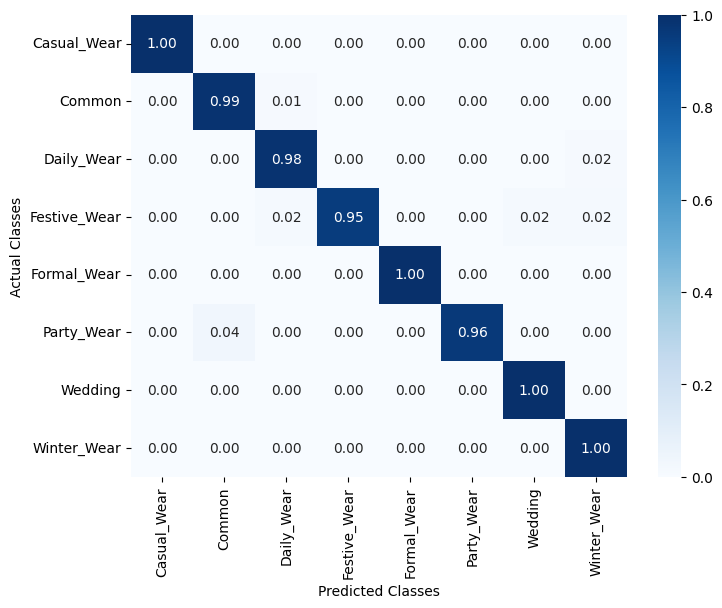

Confusion Matrix:
[[56  0  0  0  0  0  0  0]
 [ 0 66  1  0  0  0  0  0]
 [ 0  0 65  0  0  0  0  1]
 [ 0  0  1 60  0  0  1  1]
 [ 0  0  0  0 53  0  0  0]
 [ 0  2  0  0  0 51  0  0]
 [ 0  0  0  0  0  0 56  0]
 [ 0  0  0  0  0  0  0 48]]


In [43]:
import seaborn as sns

# Assuming you have the ground truth labels for the test data in a variable called 'true_labels'
#true_labels = test_batches1.classes

# Generate predictions for the test data
#predictions = model.predict(test_generator)
#predicted_labels = np.argmax(predictions, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, dstensemble)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ['Casual_Wear', 'Common', 'Daily_Wear', 'Festive_Wear', 'Formal_Wear', 'Party_Wear', 'Wedding','Winter_Wear']

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cmn, annot=True, xticklabels=labels, yticklabels=labels,cmap=plt.cm.Blues, fmt='.2f')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show(block=False)

# Generate the classification report
report = classification_report(y_true, dstensemble)

print("Confusion Matrix:")
print(cm)